# **Idea behind using Transfer learning**
Instead of training a deep network from scratch, we can actually take a pre-trained network and use it for a different task as learning of a new task relies on the previously learned tasks.

Assisting in image analysis and classification tasks including object detection with good accuracy.

We will use InceptionV3 which is a network already trained on more than a million images from the ImageNet database

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image
from PIL import ImageEnhance
from skimage.io import imread
import matplotlib.pyplot as plt

import os, random, pathlib, warnings, itertools, math
warnings.filterwarnings("ignore")

import tensorflow as tf
import tensorflow.keras.backend as K
from sklearn.metrics import confusion_matrix

from tensorflow.keras import layers, models
from tensorflow.keras.models import Model
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications import ResNet50  # Changed to ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input  # Use ResNet50 preprocess_input
from tensorflow.keras.layers import Dense, Flatten, GlobalAveragePooling2D, Dropout

# **1. Dataset Lode**

In [ ]:
!unzip "/content/animation image dataset.zip"



Archive:  /content/animation image dataset.zip
replace images/Abomasnow/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# Counting number of images in a folder. (test set in our case)

In [ ]:
def count_files(rootdir):
    '''counts the number of files in each subfolder in a directory'''
    for path in pathlib.Path(rootdir).iterdir():
        if path.is_dir():
            print("There are " + str(len([name for name in os.listdir(path) \
            if os.path.isfile(os.path.join(path, name))])) + " files in " + \
            str(path.name))

count_files(os.path.join(test_folder))

There are 2 files in Liepard
There are 2 files in Lileep
There are 2 files in Shuppet
There are 3 files in Magcargo
There are 2 files in Cradily
There are 2 files in Pikipek
There are 2 files in Spoink
There are 3 files in Snubbull
There are 2 files in Gabite
There are 2 files in Grumpig
There are 2 files in Zarude
There are 2 files in Whimsicott
There are 2 files in Fraxure
There are 5 files in Pumpkaboo
There are 2 files in Crabrawler
There are 2 files in Hydreigon
There are 2 files in Breloom
There are 3 files in Oshawott
There are 6 files in Geodude
There are 2 files in Melmetal
There are 2 files in Scatterbug
There are 2 files in Mesprit
There are 4 files in Shellder
There are 3 files in Marill
There are 3 files in Yamask
There are 2 files in Pansage
There are 2 files in Kartana
There are 1 files in Dracozolt
There are 2 files in Guzzlord
There are 3 files in Remoraid
There are 3 files in Squirtle
There are 2 files in Barboach
There are 2 files in Emboar
There are 2 files in Wynau

# **2. Image Processing**
# The goal of image processing is improvement of pictorial information for human interpretation. Basic manipulation and filtering can lead to increased understanding for feature extraction as well.

# Here we can select any vegetable of our choice and a random image from the class is displayed with comparison to a processed image.

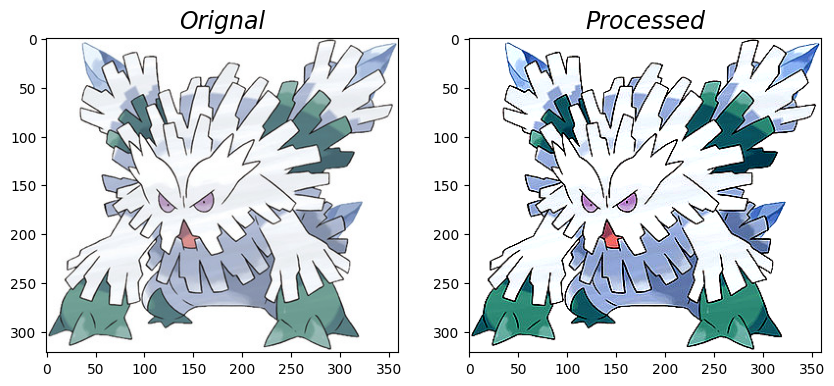

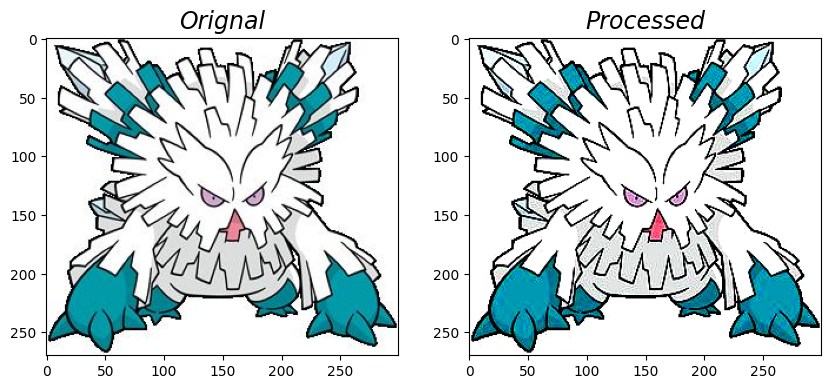

In [ ]:
image_folder="Abomasnow"  # Changed to an existing folder name in the dataset
number_of_images=2       # Number of images to display

test_folder = "/content/images"

def Preprocess():
    j=1
    for i in range(number_of_images):

        folder = os.path.join(test_folder,image_folder)
        a=random.choice(os.listdir(folder))

        image=Image.open(os.path.join(folder,a))
        image_duplicate=image.copy()
        plt.figure(figsize=(10,10))

        plt.subplot(number_of_images,2,j)
        plt.title(label='Orignal', size=17, pad='7.0', loc="center", fontstyle='italic')
        plt.imshow(image)
        j+=1

        image1=ImageEnhance.Color(image_duplicate).enhance(1.35)
        image1=ImageEnhance.Contrast(image1).enhance(1.45)
        image1=ImageEnhance.Sharpness(image1).enhance(2.5)

        plt.subplot(number_of_images,2,j)
        plt.title(label='Processed', size=17, pad='7.0', loc="center", fontstyle='italic')
        plt.imshow(image1)
        j+=1

Preprocess()

# **3. Data Visualization (EDA)**
# We can start exploring the dataset and visualize any class label (for instance, Capsicum). You can choose any vegetable to visualize the images of that class. Changing rows and columns variable also results in different format positioning of matplotlib.

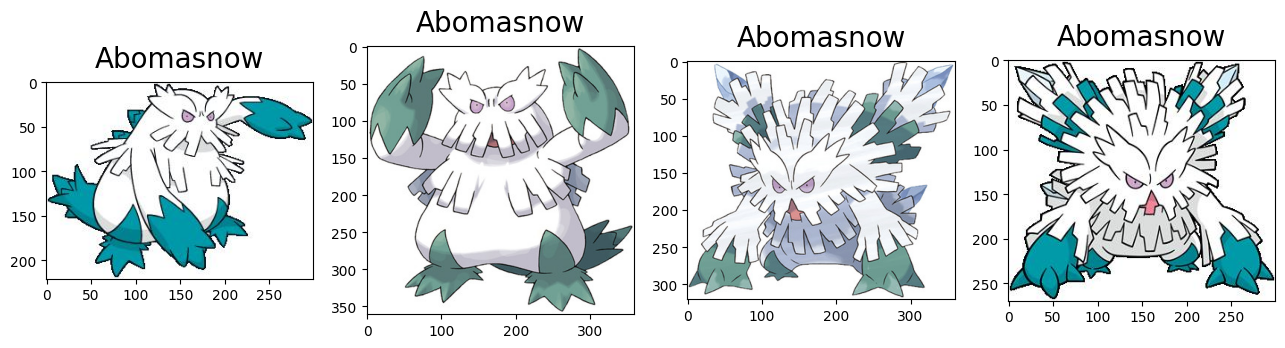

In [ ]:
select_vegetable="Abomasnow" # Changed to an existing folder name in the dataset
rows,columns = 1,5

display_folder=os.path.join(test_folder,select_vegetable) # Use test_folder which is '/content/images'
total_images=rows*columns
fig=plt.figure(1, figsize=(20, 10))

for i,j in enumerate(os.listdir(display_folder)):

    img = plt.imread(os.path.join(display_folder,j)) # Image path relative to display_folder
    fig=plt.subplot(rows, columns, i+1)
    fig.set_title(select_vegetable, pad = 11, size=20)
    plt.imshow(img)

    if i==total_images-1:
        break

# Now let's visualize the whole dataset by picking a random image from each class inside training dataset.

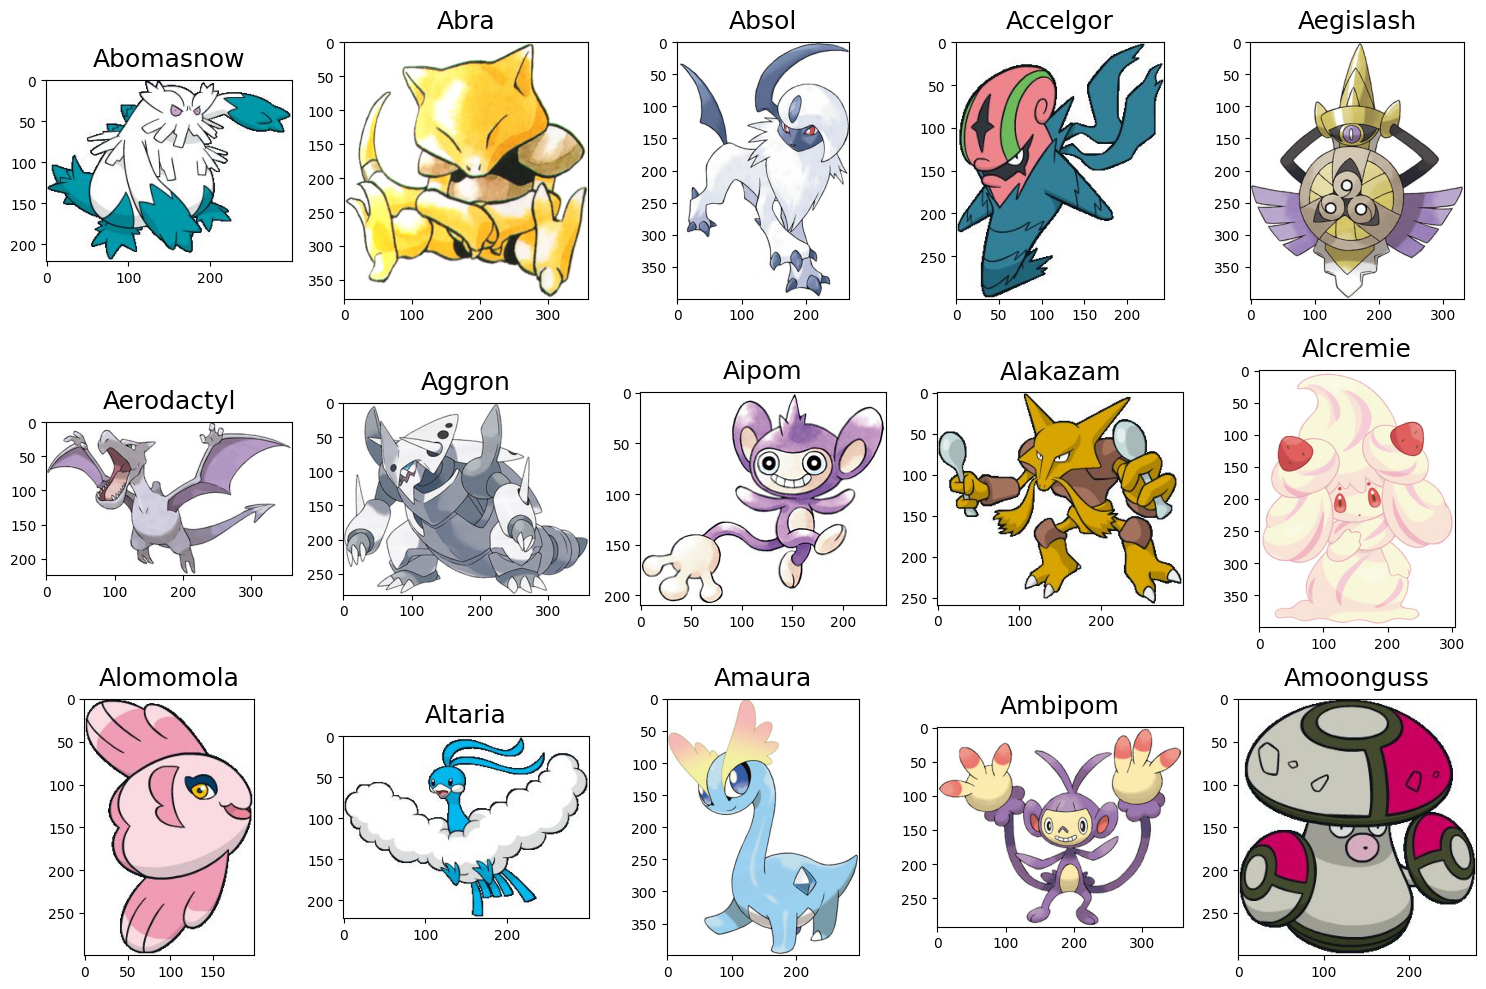

In [ ]:
images = []

# Define grid dimensions for the subplot
rows = 3
columns = 5
max_plots = rows * columns

# Collect a limited number of image paths
for food_folder in sorted(os.listdir(train_folder)):
    if len(images) >= max_plots:
        break # Stop collecting images once we have enough for the grid

    # Construct the full path to the current food category folder
    category_path = os.path.join(train_folder, food_folder)

    # Ensure it's a directory and not empty before trying to list files
    if os.path.isdir(category_path):
        food_items = os.listdir(category_path)
        if food_items: # Check if the folder contains any files
            food_selected = np.random.choice(food_items)
            images.append(os.path.join(category_path, food_selected))

fig=plt.figure(1, figsize=(15, 10))

for subplot_idx,image_path in enumerate(images):
    category=image_path.split('/')[-2]
    imgs = plt.imread(image_path)
    fig=plt.subplot(rows, columns, subplot_idx+1)
    fig.set_title(category, pad = 10,size=18)
    plt.imshow(imgs)

plt.tight_layout()

# **4. Model Building**
# Let's start building the transfer learning network to train our model using InceptionV3.

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model
import os

# Define image size
IMAGE_SIZE = [224, 224]

# Initialize the InceptionV3 model without the top classification layer and load ImageNet weights
inception = InceptionV3(input_shape=IMAGE_SIZE + [3], weights='imagenet', include_top=False)

# Freeze the layers of InceptionV3
for layer in inception.layers:
    layer.trainable = False

# Define the custom layers on top of InceptionV3
x = inception.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.2)(x)

# Final prediction layer (adjust the number of output classes as needed)
# To determine the number of classes, we need to count the number of subdirectories in train_folder
num_classes = len(os.listdir(train_folder))
prediction = Dense(num_classes, activation='softmax')(x)

# Create the model
model = Model(inputs=inception.input, outputs=prediction)

# Compile the model
model.compile(
  loss='categorical_crossentropy',
  optimizer='adam',
  metrics=['accuracy']
)

# Display model summary
model.summary()

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 111, 111,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 111, 111,  │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 111, 111,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 109, 109,  │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 109, 109,  │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 109, 109,  │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 109, 109,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 54, 54,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 54, 54,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 54, 54,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 54, 54,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 52, 52,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 52, 52,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 52, 52,    │          0 │ batch_normalizat

 Total params: 22,180,898 (84.61 MB)

 Trainable params: 378,114 (1.44 MB)

 Non-trainable params: 21,802,784 (83.17 MB)

# **5. Model Training**

In [ ]:
train_datagen = image.ImageDataGenerator(rescale = 1./255,
                                         shear_range = 0.2,
                                         zoom_range = 0.2,
                                         horizontal_flip = True)

test_datagen = image.ImageDataGenerator(rescale = 1./255)

training_set = train_datagen.flow_from_directory(
    train_folder,
    target_size = (224, 224),
    batch_size = 64,
    class_mode = 'categorical')

test_set = test_datagen.flow_from_directory(
    test_folder,
    target_size = (224, 224),
    batch_size = 64,
    class_mode = 'categorical')

Found 2503 images belonging to 898 classes.
Found 2503 images belonging to 898 classes.


In [ ]:
class_map = training_set.class_indices
class_map

{'Abomasnow': 0,
 'Abra': 1,
 'Absol': 2,
 'Accelgor': 3,
 'Aegislash': 4,
 'Aerodactyl': 5,
 'Aggron': 6,
 'Aipom': 7,
 'Alakazam': 8,
 'Alcremie': 9,
 'Alomomola': 10,
 'Altaria': 11,
 'Amaura': 12,
 'Ambipom': 13,
 'Amoonguss': 14,
 'Ampharos': 15,
 'Anorith': 16,
 'Appletun': 17,
 'Applin': 18,
 'Araquanid': 19,
 'Arbok': 20,
 'Arcanine': 21,
 'Arceus': 22,
 'Archen': 23,
 'Archeops': 24,
 'Arctovish': 25,
 'Arctozolt': 26,
 'Ariados': 27,
 'Armaldo': 28,
 'Aromatisse': 29,
 'Aron': 30,
 'Arrokuda': 31,
 'Articuno': 32,
 'Audino': 33,
 'Aurorus': 34,
 'Avalugg': 35,
 'Axew': 36,
 'Azelf': 37,
 'Azumarill': 38,
 'Azurill': 39,
 'Bagon': 40,
 'Baltoy': 41,
 'Banette': 42,
 'Barbaracle': 43,
 'Barboach': 44,
 'Barraskewda': 45,
 'Basculin': 46,
 'Bastiodon': 47,
 'Bayleef': 48,
 'Beartic': 49,
 'Beautifly': 50,
 'Beedrill': 51,
 'Beheeyem': 52,
 'Beldum': 53,
 'Bellossom': 54,
 'Bellsprout': 55,
 'Bergmite': 56,
 'Bewear': 57,
 'Bibarel': 58,
 'Bidoof': 59,
 'Binacle': 60,
 'Bisharp':

In [ ]:
r = model.fit(
  training_set,
  validation_data=test_set,
  epochs=5,
  steps_per_epoch=len(training_set),
  validation_steps=len(test_set)
)

Epoch 1/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 480s 12s/step - accuracy: 0.0035 - loss: 6.8598 - val_accuracy: 0.0036 - val_loss: 6.7720
Epoch 2/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 432s 11s/step - accuracy: 0.0034 - loss: 6.7544 - val_accuracy: 0.0068 - val_loss: 6.6608
Epoch 3/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 411s 10s/step - accuracy: 0.0055 - loss: 6.6158 - val_accuracy: 0.0152 - val_loss: 6.4254
Epoch 4/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 443s 10s/step - accuracy: 0.0150 - loss: 6.4132 - val_accuracy: 0.0280 - val_loss: 6.1376
Epoch 5/5
40/40 ━━━━━━━━━━━━━━━━━━━━ 436s 10s/step - accuracy: 0.0257 - loss: 6.1323 - val_accuracy: 0.0531 - val_loss: 5.7937


# Saving the Model

In [ ]:
model.save('model_inceptionV3_epoch5.h5')

# Accuracy and Loss Curves

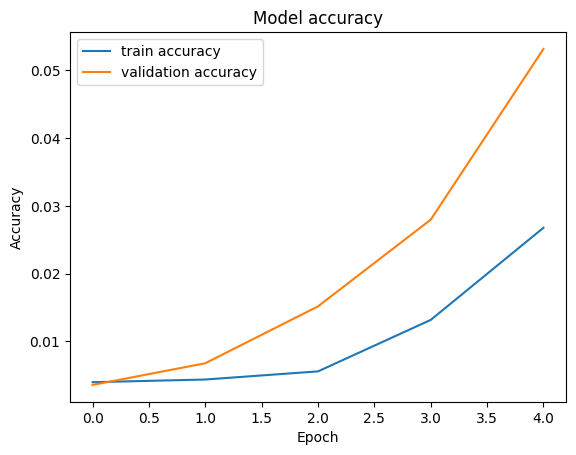

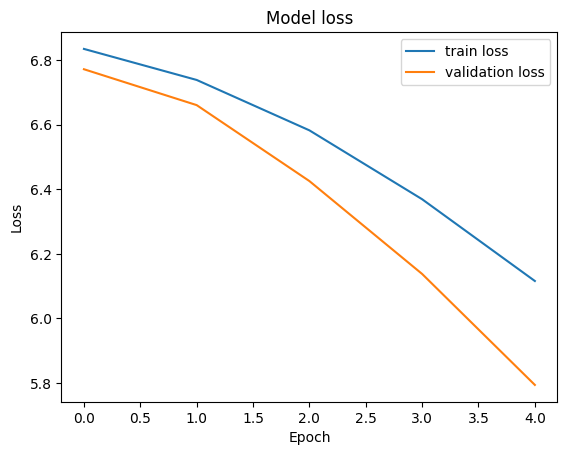

In [ ]:
def plot_accuracy(history):

    plt.plot(history.history['accuracy'],label='train accuracy')
    plt.plot(history.history['val_accuracy'],label='validation accuracy')
    plt.title('Model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='best')
    plt.savefig('Accuracy_v1_InceptionV3')
    plt.show()

def plot_loss(history):

    plt.plot(history.history['loss'],label="train loss")
    plt.plot(history.history['val_loss'],label="validation loss")
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='best')
    plt.savefig('Loss_v1_InceptionV3')
    plt.show()

plot_accuracy(r)
plot_loss(r)

# Model Layers

In [ ]:
print("Total layers in the model : ",len(model.layers),"\n")

layers = [layer.output for layer in model.layers[0:]]
layer_names = []
for layer in model.layers[0:]:
    layer_names.append(layer.name)

print("First layer : ", layer_names[0])
print("InceptionV3 layers : Layer 2 to Layer 311")
print("Our fine tuned layers : ", layer_names[311:314])
print("Final Layer : ", layer_names[314])


Total layers in the model :  315 

First layer :  input_layer_1
InceptionV3 layers : Layer 2 to Layer 311
Our fine tuned layers :  ['global_average_pooling2d', 'dense', 'dropout']
Final Layer :  dense_1


# **6. Predictions**
# Loading the model

In [ ]:
K.clear_session()
path_to_model='./model_inceptionV3_epoch5.h5'
print("Loading the model..")
model = load_model(path_to_model)
print("Done!")

Loading the model..


Done!


# Testing the model on validation set

In [ ]:
validation_data_dir = '/content/images' # Corrected path to the unzipped images

validation_datagen = image.ImageDataGenerator(rescale=1. / 255)

validation_generator = validation_datagen.flow_from_directory(
    validation_data_dir,
    target_size=(224,224),
    batch_size=64,
    class_mode='categorical')

scores = model.evaluate(validation_generator) # Changed to model.evaluate
print("Test Accuracy: {:.3f}".format(scores[1]))

Found 2503 images belonging to 898 classes.
40/40 ━━━━━━━━━━━━━━━━━━━━ 202s 5s/step - accuracy: 0.0549 - loss: 5.8298
Test Accuracy: 0.053


# Functions to predict the output of our model

In [ ]:
category = {v: k for k, v in training_set.class_indices.items()}

def predict_image(filename,model):
    img_ = image.load_img(filename, target_size=(224, 224))
    img_array = image.img_to_array(img_)
    img_processed = np.expand_dims(img_array, axis=0)
    img_processed /= 255.

    prediction = model.predict(img_processed)
    index = int(np.argmax(prediction)) # Explicitly cast to int

    plt.title("Prediction - {}".format(category[index]))
    plt.imshow(img_array)

def predict_dir(filedir,model):
    cols=3
    pos=0
    images=[]
    total_images=len(os.listdir(filedir))
    rows=total_images//cols + 1

    true=filedir.split('/')[-1]

    for i in sorted(os.listdir(filedir)):
        images.append(os.path.join(filedir,i))

    for subplot, imggg in enumerate(images):
        img_ = image.load_img(imggg, target_size=(224, 224))
        img_array = image.img_to_array(img_)
        img_processed = np.expand_dims(img_array, axis=0)
        img_processed /= 255.
        prediction = model.predict(img_processed)
        index = int(np.argmax(prediction)) # Explicitly cast to int

        pred=category.get(index)
        if pred==true:
            pos+=1

    acc=pos/total_images
    print("Accuracy for {orignal}: {:.2f} ({pos}/{total})".format(acc,pos=pos,total=total_images,orignal=true))

# Single image prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step


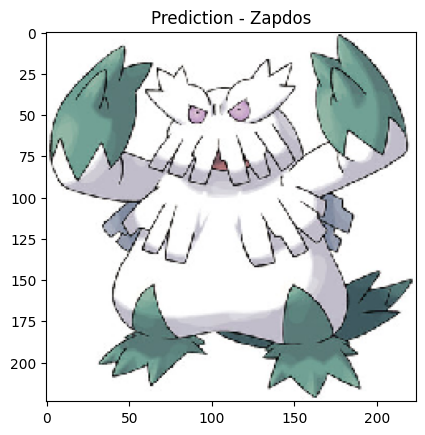

In [ ]:
predict_image(os.path.join(validation_folder,'Abomasnow/0.jpg'),model)

# Validation directory accuracy prediction

In [ ]:
for i in os.listdir(validation_folder):
    predict_dir(os.path.join(validation_folder,i),model)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
Accuracy for Liepard: 0.00 (0/2)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
Accuracy for Lileep: 0.00 (0/2)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
Accuracy for Shuppet: 0.00 (0/2)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step
Accuracy for Magcargo: 0.00 (0/3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Accuracy for Cradily: 0.00 (0/2)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
Accuracy for Pikipek: 0.00 (0/2)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
Accuracy for Spoink: 0.00 (0/2)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
Accuracy for Snubbull: 0.00 (0/3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/

# **7. Evaluation**
# Loading the model
# Confusion Matrix for evaluating the performance of our classification model.

In [ ]:
def labels_confusion_matrix(validation_folder):

    folder_path=validation_folder

    mapping={}
    for i,j in enumerate(sorted(os.listdir(folder_path))):
        mapping[j]=i

    files=[]
    real=[]
    predicted=[]

    for i in os.listdir(folder_path):

        true=os.path.join(folder_path,i)
        true=true.split('/')[-1]
        true=mapping[true]

        for j in os.listdir(os.path.join(folder_path,i)):

            img_ = image.load_img(os.path.join(folder_path,i,j), target_size=(224,224))
            img_array = image.img_to_array(img_)
            img_processed = np.expand_dims(img_array, axis=0)
            img_processed /= 255.
            prediction = model.predict(img_processed)
            index = np.argmax(prediction)

            predicted.append(index)
            real.append(true)

    return (real,predicted)

def print_confusion_matrix(real,predicted):
    total_output_labels = 15
    cmap="turbo"
    cm_plot_labels = [i for i in range(15)]

    cm = confusion_matrix(y_true=real, y_pred=predicted)
    df_cm = pd.DataFrame(cm,cm_plot_labels,cm_plot_labels)
    sns.set(font_scale=1.2) # for label size
    plt.figure(figsize = (15,10))
    s=sns.heatmap(df_cm,fmt="d", annot=True,cmap=cmap) # font size

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.savefig('confusion_matrix.png')
    plt.show()